# Modelo Visual (CNN)

Classificação de gênero musical no GTZAN usando uma CNN sobre os espectrogramas.

In [4]:
from google.colab import drive
drive.mount('/content/drive')
import os

PROJECT = '/content/drive/MyDrive/gtzan_projeto'

pastas = [
    'data/raw',
    'data/processed/tabular',
    'data/processed/images',
    'modelos',
    'resultados',
]
for p in pastas:
    os.makedirs(f'{PROJECT}/{p}', exist_ok=True)

print('Drive montado. Projeto em:', PROJECT)
print('Pastas criadas:')
for p in pastas:
    print(f'  {PROJECT}/{p}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado. Projeto em: /content/drive/MyDrive/gtzan_projeto
Pastas criadas:
  /content/drive/MyDrive/gtzan_projeto/data/raw
  /content/drive/MyDrive/gtzan_projeto/data/processed/tabular
  /content/drive/MyDrive/gtzan_projeto/data/processed/images
  /content/drive/MyDrive/gtzan_projeto/modelos
  /content/drive/MyDrive/gtzan_projeto/resultados


## 1. Carregar os dados de A

In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Espectrogramas (N,128,128) já normalizados 0-1 -> float32 e com eixo de canal
# (N,128,128,1), formato que as camadas Conv2D esperam.
def load_images(split):
    X = np.load(f'{IMG}/X_{split}.npy').astype('float32')
    return X[..., np.newaxis]

X_train = load_images('train')
X_val   = load_images('val')
X_test  = load_images('test')

y_train = np.load(f'{IMG}/y_train.npy', allow_pickle=True)
y_val   = np.load(f'{IMG}/y_val.npy', allow_pickle=True)
y_test  = np.load(f'{IMG}/y_test.npy', allow_pickle=True)

# Rótulos de texto ('blues', ...) -> inteiros 0-9. Encoder ajustado só no treino.
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print('Shape treino:', X_train.shape)
print('Classes:', list(le.classes_))

Shape treino: (699, 128, 128, 1)
Classes: [np.str_('blues'), np.str_('classical'), np.str_('country'), np.str_('disco'), np.str_('hiphop'), np.str_('jazz'), np.str_('metal'), np.str_('pop'), np.str_('reggae'), np.str_('rock')]


## 2. Construir a CNN

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn(input_shape=(128, 128, 1), num_classes=10):
    # BatchNormalization removido (travava o treino em ~10% com poucos dados);
    # o restante segue o guia.
    model = models.Sequential([
        # Bloco 1 - texturas básicas do espectrograma
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloco 2 - padrões intermediários
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloco 3 - padrões mais abstratos
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Cabeça de classificação
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ])
    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,106 (32.36 MB)

 Trainable params: 8,484,106 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Treinar a CNN

In [7]:
from tensorflow.keras import callbacks

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# EarlyStopping: para se a acurácia de validação não melhorar por 10 épocas.
cb_early = callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

# ReduceLROnPlateau: reduz o learning rate pela metade se a val_loss estagnar.
cb_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=50, batch_size=32,
    callbacks=[cb_early, cb_lr],
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 363ms/step - accuracy: 0.0973 - loss: 2.4410 - val_accuracy: 0.1000 - val_loss: 2.3024 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0973 - loss: 2.3007 - val_accuracy: 0.1933 - val_loss: 2.2942 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1488 - loss: 2.2758 - val_accuracy: 0.1933 - val_loss: 2.2169 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1702 - loss: 2.1802 - val_accuracy: 0.2267 - val_loss: 2.1296 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2074 - loss: 2.1221 - val_accuracy: 0.2867 - val_loss: 2.0319 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1874 - loss: 2.0913 - val_accuracy: 0.2867 - val_loss: 2.0003 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2532 - loss: 2.0086 - val_a

## 4. Curvas de treino e matriz de confusão (validação)

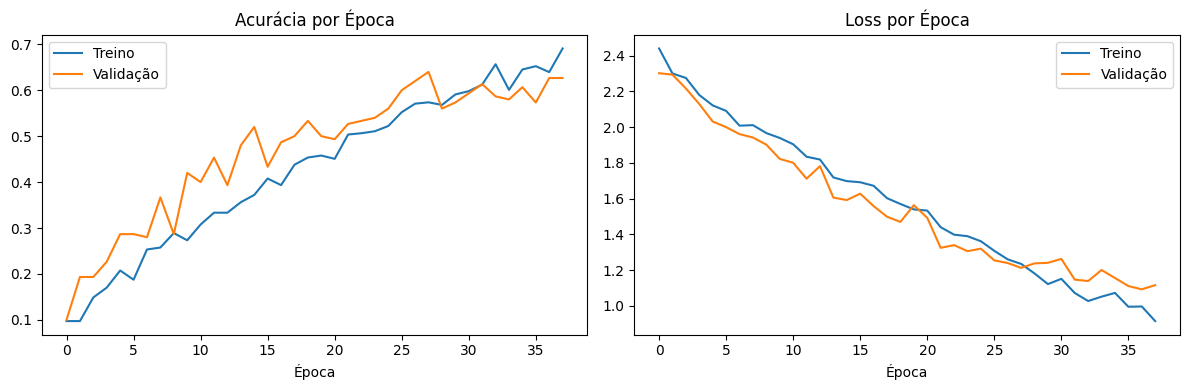

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
              precision    recall  f1-score   support

       blues       0.67      0.53      0.59        15
   classical       0.80      0.80      0.80        15
     country       0.43      0.60      0.50        15
       disco       0.58      0.47      0.52        15
      hiphop       0.80      0.80      0.80        15
        jazz       0.64      0.60      0.62        15
       metal       0.93      0.93      0.93        15
         pop       0.63      0.80      0.71        15
      reggae       0.73      0.53      0.62        15
        rock       0.31      0.33      0.32        15

    accuracy                           0.64       150
   macro avg       0.65      0.64      0.64       150
weighted avg       0.65      0.64      0.64       150



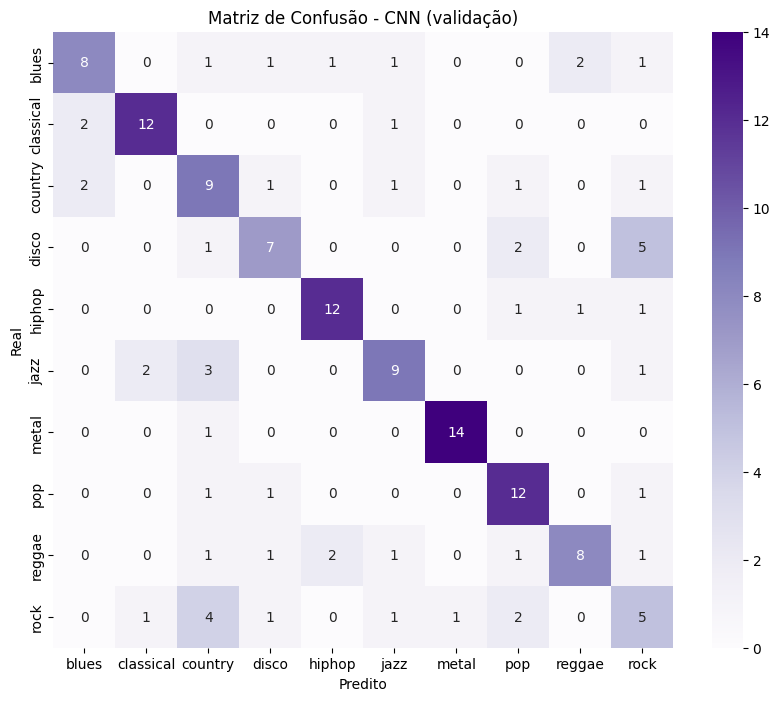

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Curvas de acurácia e perda por época
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Treino')
axes[0].plot(history.history['val_accuracy'], label='Validação')
axes[0].set_title('Acurácia por Época'); axes[0].set_xlabel('Época'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Treino')
axes[1].plot(history.history['val_loss'], label='Validação')
axes[1].set_title('Loss por Época'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{PROJECT}/resultados/cnn_training_curves.png', dpi=150)
plt.show()

# Matriz de confusão na validação + F1 por gênero
y_pred_val = np.argmax(model.predict(X_val), axis=1)
print(classification_report(y_val_enc, y_pred_val, target_names=le.classes_))

cm = confusion_matrix(y_val_enc, y_pred_val)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
plt.title('Matriz de Confusão - CNN (validação)')
plt.xlabel('Predito'); plt.ylabel('Real')
plt.savefig(f'{PROJECT}/resultados/confusion_matrix_cnn.png', dpi=150)
plt.show()

## 5. Avaliação final no teste (rodar UMA vez, no final)

`y_pred_cnn_test.npy` fica alinhado ao conjunto de teste das imagens. No notebook de comparação, a CNN deve ser avaliada contra `data/processed/images/y_test.npy` (não o `y_test` tabular).

In [9]:
from sklearn.metrics import accuracy_score

y_pred_test = np.argmax(model.predict(X_test), axis=1)
acc_test = accuracy_score(y_test_enc, y_pred_test)
print(f'Acurácia FINAL no teste: {acc_test:.4f}')

model.save(f'{PROJECT}/modelos/cnn_final.keras')
np.save(f'{PROJECT}/resultados/y_pred_cnn_test.npy', y_pred_test)
print('Modelo e predições salvos.')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Acurácia FINAL no teste: 0.5133
Modelo e predições salvos.
